In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import Normalize
import torch

converged


/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_55328/1219743307.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_55328/1219743307.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_55328/1219743307.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_55328/1219743307.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tic

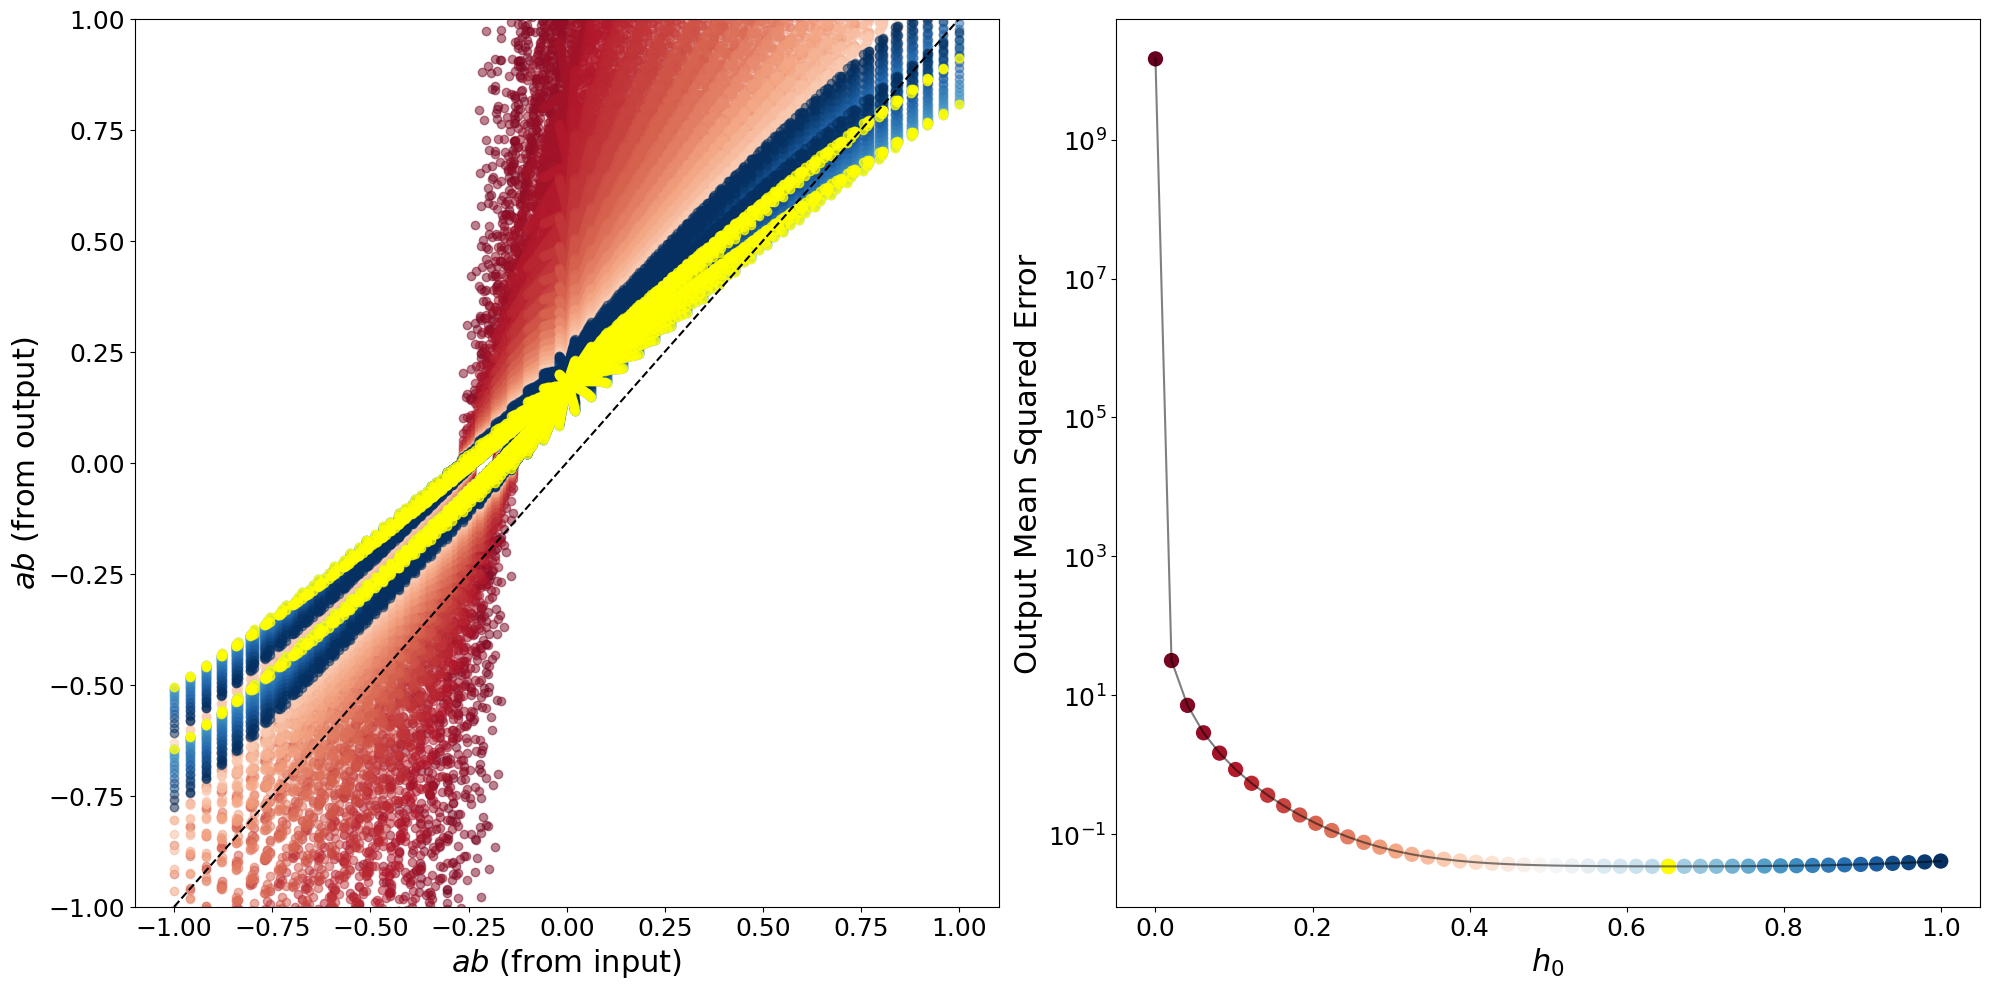

In [6]:
max_iter = 200
tol = 1e-10
damping = 0.7 
n_h_0 = 50
n_inputs = 50
n_neurons = 10000


phi = lambda x: np.tanh(x)
d1phi = lambda x: 1 - np.tanh(x)**2
d2phi = lambda x: -2*np.tanh(x) + 2*np.tanh(x)**3
d3phi = lambda x: -2 + 8*np.tanh(x)**2 - 6*np.tanh(x)**4
d4phi = lambda x: 16*np.tanh(x) - 40*np.tanh(x)**3 + 24*np.tanh(x)**5


sigma_m = 1
sigma_n = 0.3
sigma_I = 0.3
rho_mn = 0
rho_nI = 1

cov = np.diag([sigma_m, sigma_n, sigma_I, sigma_I])**2

aa, bb = np.meshgrid( np.linspace(-1, 1, n_inputs), np.linspace(-1, 1, n_inputs) )
aa, bb = aa.flatten(), bb.flatten()

def make_correlated_samples(L, seed=0):
    dim = L.shape[0]
    x = np.random.normal(loc=0, scale=1, size=(dim, n_neurons))
    z = np.einsum('ij, jn -> in', L, x)    
    return z


L = np.linalg.cholesky(cov)
z = make_correlated_samples(L)

m = z[0]
n_perp = z[1]
IA = z[2]   
IB = z[3]   
n = n_perp + (rho_nI/sigma_I**2)*IA*IB

c = 1


kappa = np.zeros((n_inputs**2))                    # 2, n_inputs

for _ in range(max_iter):

    h = c +\
        np.einsum('i, u -> iu', m, kappa) +\
        np.einsum('i, u -> iu', IA, aa) +\
        np.einsum('i, u -> iu', IB, bb) 

    kappa_new = (1/n_neurons) * np.einsum('i, iu -> u', n, phi( h ))

    err = np.max(np.abs(kappa_new - kappa))
    kappa = damping * kappa_new + (1.0 - damping) * kappa

    if err < tol:
        print('converged')
        break
 


h_0 = np.linspace(1e-6, 1, n_h_0)
w = 1 / (d2phi(h_0) * rho_nI * sigma_I**2)    

est_ab = np.einsum('h, u -> hu', w, kappa)       
target_ab = (aa * bb)[None,:]

error = np.square( est_ab - target_ab ).mean(axis=1)                         # (n_h_0,)

best_h_0 = np.argmin( error )


fig, ax = plt.subplots(1, 2, figsize=(20,10))

cmap = colormaps.get_cmap('RdBu')
norm = Normalize(vmin=h_0[0], vmax=h_0[-1])
for i, h in enumerate(h_0):
    ax[0].scatter(target_ab, est_ab[i], color=cmap(norm(h)), alpha=0.5)
ax[0].scatter(target_ab, est_ab[best_h_0], color='yellow', alpha=0.75)
ax[0].set_ylim((-1, 1))
ax[0].plot(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100), ls='--', color='k')
ax[0].set_xlabel(r'$ab$ (from input)', fontsize=22)
ax[0].set_ylabel(r'$ab$ (from output)', fontsize=22)
ax[0].set_xticklabels(ax[0].get_xticklabels(), fontsize=18)
ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=18)

ax[1].plot(h_0, error, c='k', alpha=0.5)
ax[1].scatter(h_0, error, c=cmap(norm(h_0)), s=100)
ax[1].scatter(h_0[ best_h_0 ], error[ best_h_0 ], color='yellow', s=100)
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$h_0$', fontsize=22)
ax[1].set_ylabel('Output Mean Squared Error', fontsize=22)
ax[1].set_xticklabels(ax[1].get_xticklabels(), fontsize=18)
ax[1].set_yticklabels(ax[1].get_yticklabels(), fontsize=18)

plt.tight_layout()

plt.show()

converged


/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_55395/1481411444.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_55395/1481411444.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_55395/1481411444.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_55395/1481411444.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set

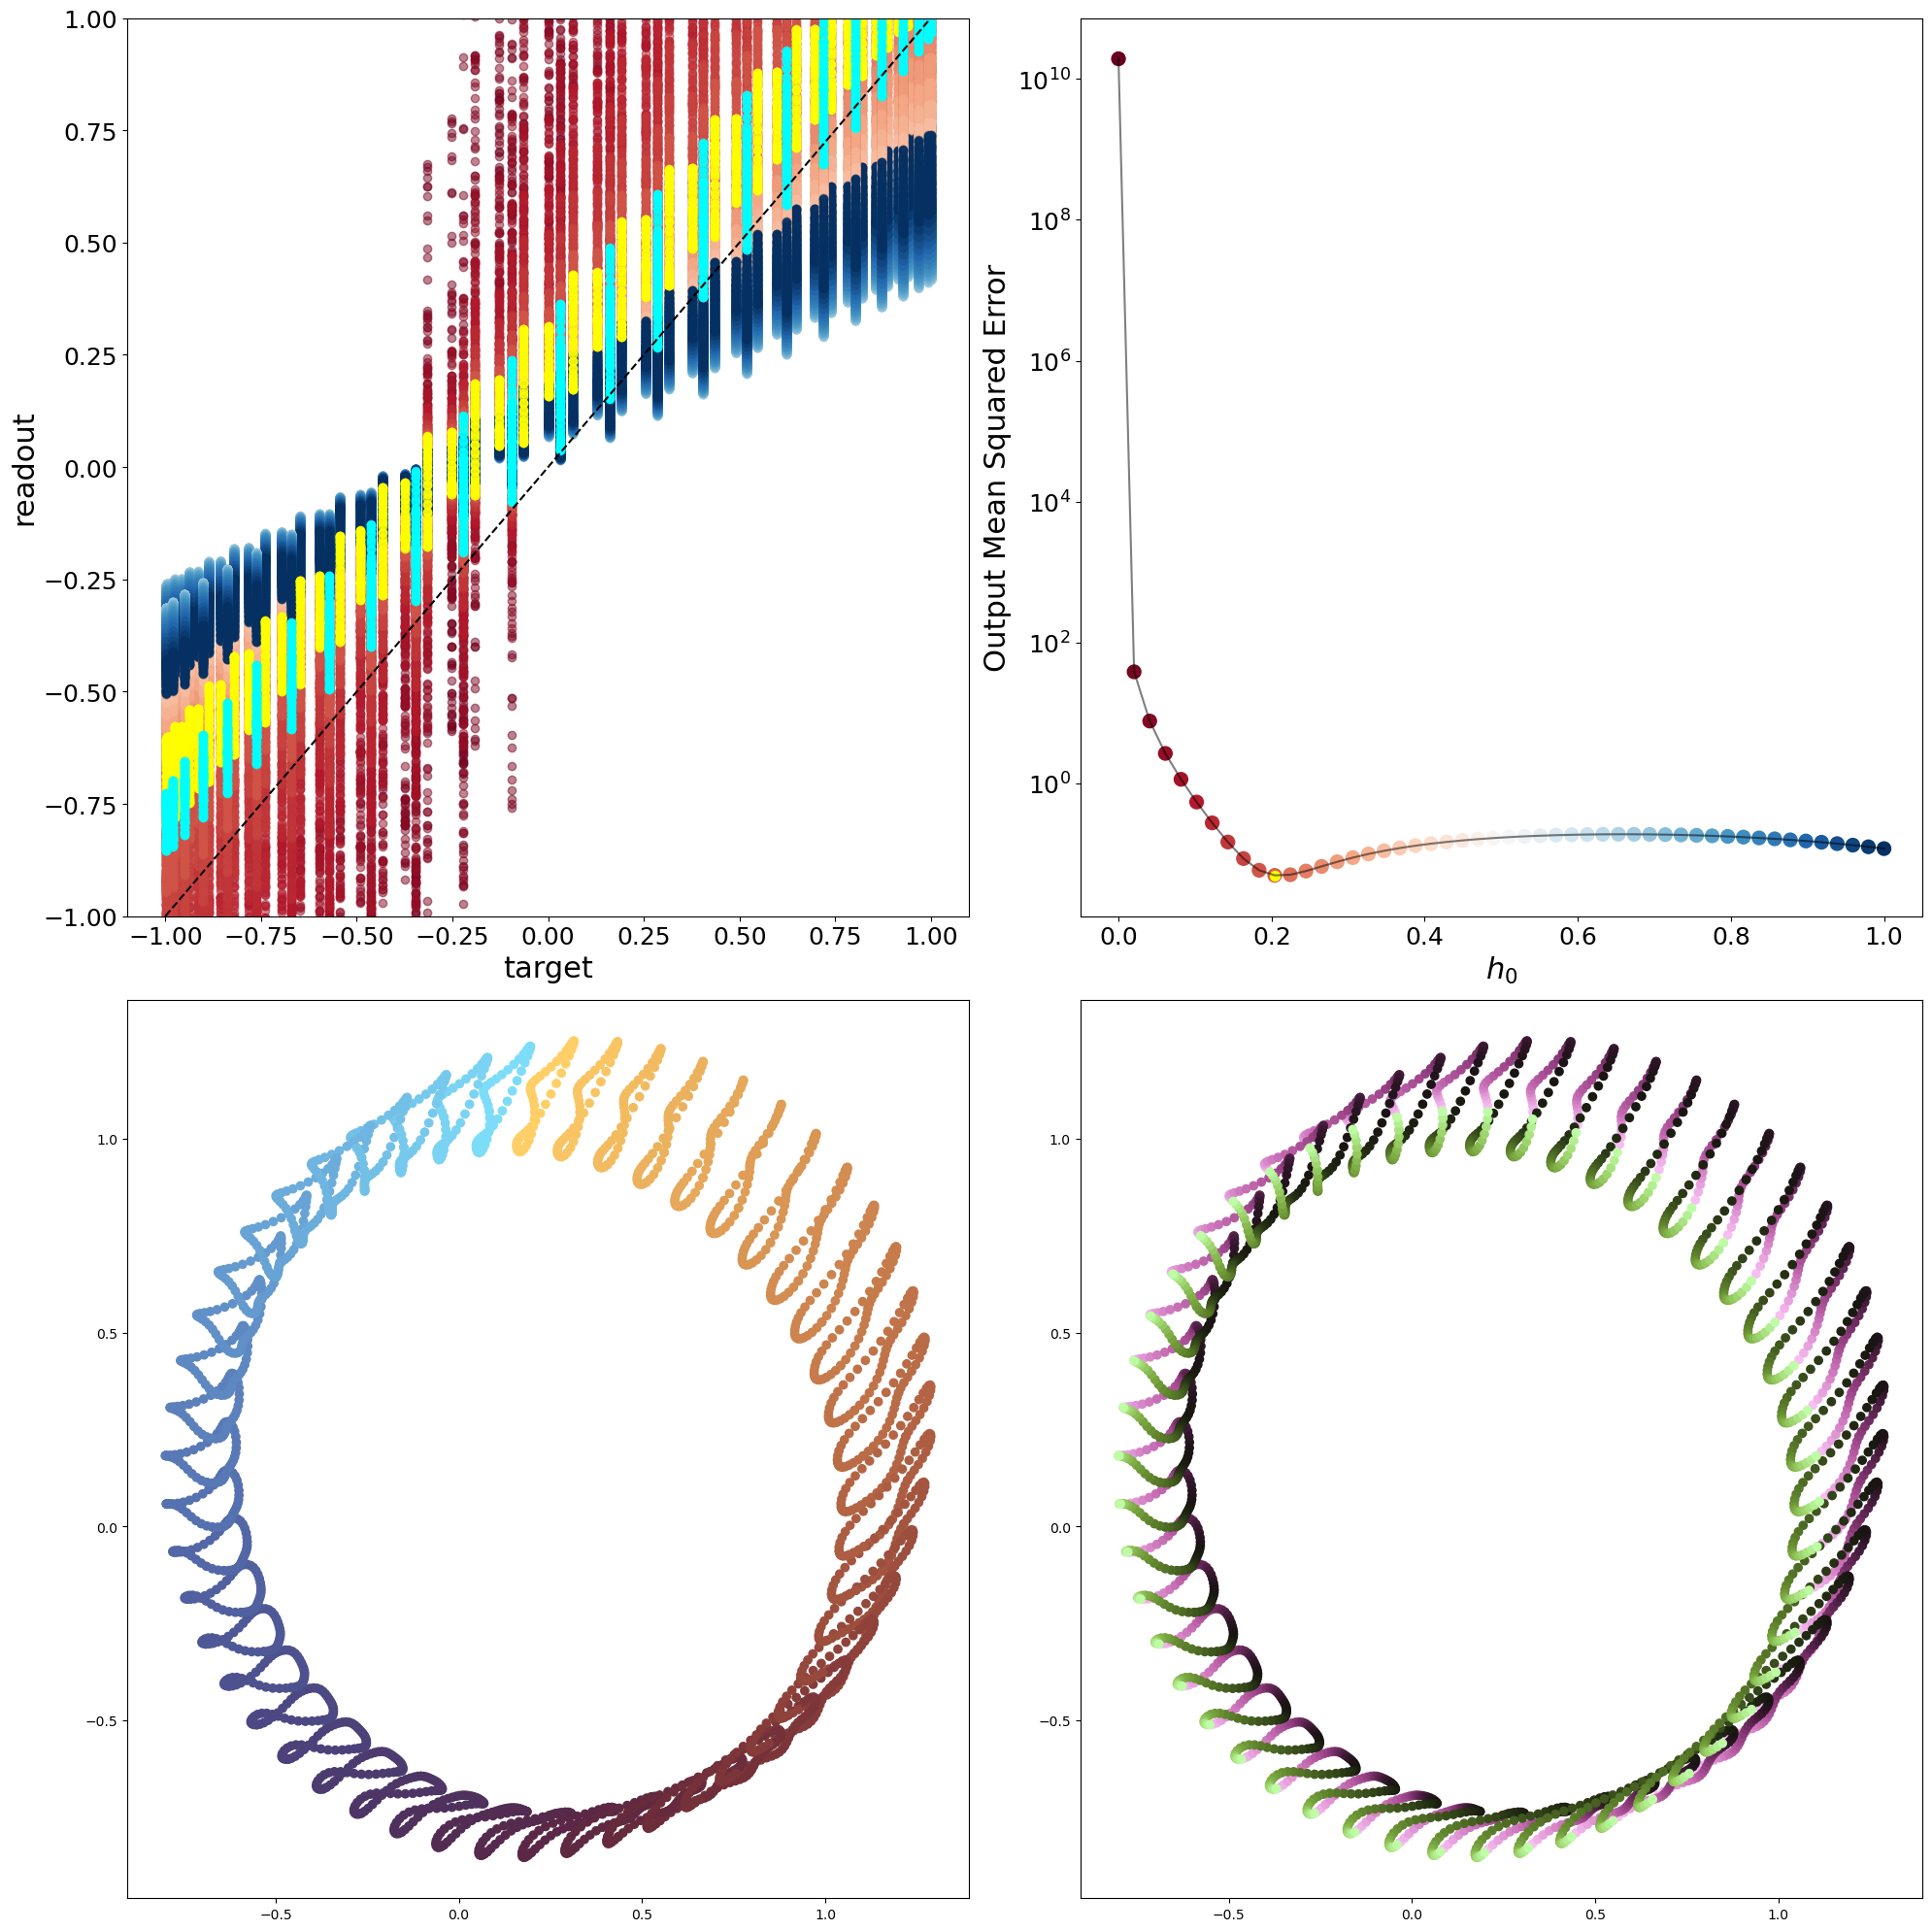

In [2]:
max_iter = 200
tol = 1e-10
damping = 0.7 
n_h_0 = 50
n_inputs = 50
n_neurons = 10000

# phi = lambda x: np.log( 1 + np.exp( x ) )
# d1phi = lambda x: np.exp( x ) / (1 + np.exp( x ))
# d2phi = lambda x: np.exp( x ) / np.square( 1 + np.exp( x ) )
# d3phi = lambda x: ( np.exp( x ) - np.exp( 3*x )) / np.power(1 + np.exp( x ), 4)

phi = lambda x: np.tanh(x)
d1phi = lambda x: 1 - np.tanh(x)**2
d2phi = lambda x: -2*np.tanh(x) + 2*np.tanh(x)**3
d3phi = lambda x: -2 + 8*np.tanh(x)**2 - 6*np.tanh(x)**4
d4phi = lambda x: 16*np.tanh(x) - 40*np.tanh(x)**3 + 24*np.tanh(x)**5


sigma_m = 0.5
sigma_n = 0.3
sigma_I = 0.3
rho_nI_1 = 1
rho_nI_2 = 1
J_1 = 1
J_2 = 1

cov = sigma_I**2 * np.eye(4)

t1, t2 = np.meshgrid( np.linspace(0, 2*np.pi, n_inputs) , np.linspace(0, 2*np.pi, n_inputs))
t1, t2 = t1.flatten(), t2.flatten()
U1, U2, U3, U4 = np.sin( t1 ), np.cos( t1 ), np.sin( t2 ), np.cos( t2 )
T1, T2 = np.sin( t2 - t1 ), np.cos( t2 - t1 )

def make_correlated_samples(L, seed=0):
    dim = L.shape[0]
    x = np.random.normal(loc=0, scale=1, size=(dim, n_neurons))
    z = np.einsum('ij, jn -> in', L, x)    

    theta = np.random.uniform(low=0, high=2*np.pi, size=(1, n_neurons))

    return np.concatenate((theta, z), axis=0)


L = np.linalg.cholesky(cov)
z = make_correlated_samples(L)

m1 = np.sqrt(J_1) *  np.cos( z[0] )
m2 = np.sqrt(J_2) * np.sin( z[0] )
n1_perp = np.sqrt(J_1) * np.cos( z[0] )
n2_perp = np.sqrt(J_2) * np.sin( z[0] )
I1 = z[1]   
I2 = z[2]   
I3 = z[3]
I4 = z[4]
n1 = n1_perp + (rho_nI_1 / sigma_I**2)*(I2*I3 - I1*I4)
n2 = n2_perp + (rho_nI_2 / sigma_I**2)*(I1*I3 + I2*I4)

c = 0.5


kappa = np.zeros((2, n_inputs**2))                    # 2, n_inputs
m = np.stack((m1, m2), axis=0)                        # 2, n_neurons
n = np.stack((n1, n2), axis=0)                        # 2, n_neurons
b = np.stack((I1, I2, I3, I4), axis=0)                # 4, n_neurons
u = np.stack((U1, U2, U3, U4), axis=0)                    # 4, n_inputs

for _ in range(max_iter):

    h = c +\
        np.einsum('ri, ru -> iu', m, kappa) +\
        np.einsum('ki, ku -> iu', b, u) 

    kappa_new = (1/n_neurons) * np.einsum('ri, iu -> ru', n, phi( h ))

    err = np.max(np.abs(kappa_new - kappa))
    kappa = damping * kappa_new + (1.0 - damping) * kappa

    if err < tol:
        print('converged')
        break
 


h_0 = np.linspace(1e-6, 1, n_h_0)

w1 = (1 - 0.5*(d1phi(h_0) - d2phi(h_0)*h_0) * J_1) / (d2phi(h_0) * rho_nI_1 * sigma_I**2)  
w2 = (1 - 0.5*(d1phi(h_0) - d2phi(h_0)*h_0) * J_2) / (d2phi(h_0) * rho_nI_2 * sigma_I**2)    
w = np.stack((w1, w2), axis=1)

pred = np.einsum('hr, ru -> hru', w, kappa)       
target = np.stack((T1, T2), axis=0)

error = np.square( pred - target[None,:,:] ).mean(axis=(1,2))                         # (n_h_0,)

best_h_0 = np.argmin( error )


from matplotlib.cm import ScalarMappable
fig, ax = plt.subplots(2, 2, figsize=(20,20))
ax = ax.flatten()


cmap = colormaps.get_cmap('RdBu')
norm = Normalize(vmin=h_0[0], vmax=h_0[-1])
for k in range(2):
    for i, h in enumerate(h_0):
        ax[0].scatter(target[k], pred[i,k], color=cmap(norm(h)), alpha=0.5)
for k in range(2):
    ax[0].scatter(target[k], pred[best_h_0, k], color=['yellow', 'cyan'][k], alpha=0.75)
ax[0].set_ylim((-1, 1))
ax[0].plot(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100), ls='--', color='k')
ax[0].set_xlabel(r'target', fontsize=22)
ax[0].set_ylabel(r'readout', fontsize=22)
ax[0].set_xticklabels(ax[0].get_xticklabels(), fontsize=18)
ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=18)

ax[1].plot(h_0, error, c='k', alpha=0.5)
ax[1].scatter(h_0, error, c=cmap(norm(h_0)), s=100)
ax[1].scatter(h_0[ best_h_0 ], error[ best_h_0 ], color='yellow', s=50)
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$h_0$', fontsize=22)
ax[1].set_ylabel('Output Mean Squared Error', fontsize=22)
ax[1].set_xticklabels(ax[1].get_xticklabels(), fontsize=18)
ax[1].set_yticklabels(ax[1].get_yticklabels(), fontsize=18)

t1_cmap = colormaps.get_cmap('managua')
t2_cmap = colormaps.get_cmap('vanimo')
angle_norm = Normalize(vmin=0, vmax=2*np.pi)
ax[2].scatter(pred[best_h_0,0], pred[best_h_0,1], c=t1_cmap(angle_norm((t2 - t1)%(2*np.pi))))
ax[3].scatter(pred[best_h_0,0], pred[best_h_0,1], c=t2_cmap(angle_norm(t2)))

plt.tight_layout()

plt.show()

In [ ]:
max_iter = 200
tol = 1e-10
damping = 0.7 
n_h_0 = 50
n_inputs = 50
n_neurons = 1000
n_samples = 100
n_epochs = 100
lr = 0.01

phi = lambda x: torch.tanh(x)
d1phi = lambda x: 1 - torch.tanh(x)**2
d2phi = lambda x: -2*torch.tanh(x) + 2*torch.tanh(x)**3
d3phi = lambda x: -2 + 8*torch.tanh(x)**2 - 6*torch.tanh(x)**4
d4phi = lambda x: 16*torch.tanh(x) - 40*torch.tanh(x)**3 + 24*torch.tanh(x)**5

t1, t2 = torch.meshgrid( torch.linspace(0, 2*torch.pi, n_inputs) , torch.linspace(0, 2*torch.pi, n_inputs))
t1, t2 = t1.flatten(), t2.flatten()
U1, U2, U3, U4 = torch.sin( t1 ), torch.cos( t1 ), torch.sin( t2 ), torch.cos( t2 )
T1, T2 = torch.sin( t2 - t1 ), torch.cos( t2 - t1 )

sigma_I = torch.tensor([1], requires_grad=True, dtype=torch.float32)
rho_nI_1 = torch.tensor([1], requires_grad=True, dtype=torch.float32)
rho_nI_2 = torch.tensor([1], requires_grad=True, dtype=torch.float32)
J_1 = torch.tensor([1], requires_grad=True, dtype=torch.float32)
J_2 = torch.tensor([1], requires_grad=True, dtype=torch.float32)
h_0 = torch.tensor([1], requires_grad=True, dtype=torch.float32)

def make_correlated_samples(L):
    dim = L.shape[0]
    x = torch.randn(size=(dim, n_samples, n_neurons))
    z = torch.einsum('ij, jsn -> isn', L, x)    

    theta = torch.rand(size=(1, n_samples, n_neurons)) * 2*np.pi

    return torch.concatenate((theta, z), axis=0)

for e in range(n_epochs):
    cov = sigma_I**2 * torch.eye(4)
    L = torch.linalg.cholesky(cov)
    z = make_correlated_samples(L)

    m1 = torch.sqrt(J_1) *  torch.cos( z[0] )
    m2 = torch.sqrt(J_2) * torch.sin( z[0] )
    n1_perp = torch.sqrt(J_1) * torch.cos( z[0] )
    n2_perp = torch.sqrt(J_2) * torch.sin( z[0] )
    I1 = z[1]   
    I2 = z[2]   
    I3 = z[3]
    I4 = z[4]
    n1 = n1_perp + (rho_nI_1 / sigma_I**2)*(I2*I3 - I1*I4)
    n2 = n2_perp + (rho_nI_2 / sigma_I**2)*(I1*I3 + I2*I4)

    c = 0.5


    kappa = torch.zeros((2, n_samples, n_inputs**2))         # 2, n_samples, n_inputs
    m = torch.stack((m1, m2), axis=0)                        # 2, n_samples, n_neurons
    n = torch.stack((n1, n2), axis=0)                        # 2, n_samples, n_neurons
    b = torch.stack((I1, I2, I3, I4), axis=0)                # 4, n_samples, n_neurons
    u = torch.stack((U1, U2, U3, U4), axis=0)                # 4, n_inputs

    for _ in range(max_iter):

        h = c +\
            torch.einsum('rsi, rsu -> isu', m, kappa) +\
            torch.einsum('ksi, ku -> isu', b, u) 

        kappa_new = (1/n_neurons) * torch.einsum('rsi, isu -> rsu', n, phi( h ))

        err = torch.max(torch.abs(kappa_new - kappa))
        kappa = damping * kappa_new + (1.0 - damping) * kappa

        if err < tol:
            break
    

    w1 = (1 - 0.5*(d1phi(h_0) - d2phi(h_0)*h_0) * J_1) / (d2phi(h_0) * rho_nI_1 * sigma_I**2)  
    w2 = (1 - 0.5*(d1phi(h_0) - d2phi(h_0)*h_0) * J_2) / (d2phi(h_0) * rho_nI_2 * sigma_I**2)    
    w = torch.stack((w1, w2), dim=0)

    pred = torch.einsum('r, rsu -> rsu', w, kappa)       
    target = torch.stack((T1, T2), axis=0)

    error = torch.square( pred - target[:,None,:] ).mean()                         
main

    error.backward()
    with torch.no_grad():
        for p in [sigma_I, rho_nI_1, rho_nI_2, J_1, J_2, h_0]:
            p -= lr * p.grad
            p.grad.zero_()

    print(f'[{e}] {error:.4f}')
